# NBA Shot Data 

## Dependencies

In [84]:
from nba_api.stats.endpoints import shotchartdetail, playercareerstats
from nba_api.stats.static import players, teams
from modules.datasets import NbaScraper
from modules.charts.charts import ShotCharts
import json
import requests
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Data Preparing

In [85]:
# The NbaScraper class is responsible for retrieving data through web scraping and the NBA API.

# Get player id
name = "LeBron James"
id = NbaScraper.get_json_from_name(name)['id']

print(id)
career = NbaScraper.get_player_career(id)
teams = ['LAL']
team_ids = list(set(career[career.TEAM_ABBREVIATION.isin(teams)].TEAM_ID.values))

seasons = ['2023-24']
shot_data = NbaScraper.get_shot_data(id, team_ids, seasons)

#shot_data = shot_data[shot_data.GAME_ID == max(shot_data.GAME_ID)]
df = pd.DataFrame(shot_data)
df.to_excel("shot_data.xlsx", index=False)

2544


## Pre-processing 

In [86]:
# ====== 1. Check Data Quality ======

# Missing Value Check
missing_values = df.isnull().sum()
print("Missing value statistics:\n", missing_values)

Missing value statistics:
 GRID_TYPE              0
GAME_ID                0
GAME_EVENT_ID          0
PLAYER_ID              0
PLAYER_NAME            0
TEAM_ID                0
TEAM_NAME              0
PERIOD                 0
MINUTES_REMAINING      0
SECONDS_REMAINING      0
EVENT_TYPE             0
ACTION_TYPE            0
SHOT_TYPE              0
SHOT_ZONE_BASIC        0
SHOT_ZONE_AREA         0
SHOT_ZONE_RANGE        0
SHOT_DISTANCE          0
LOC_X                  0
LOC_Y                  0
SHOT_ATTEMPTED_FLAG    0
SHOT_MADE_FLAG         0
GAME_DATE              0
HTM                    0
VTM                    0
dtype: int64


In [87]:
# Ensure that SHOT_MADE_FLAG contains only 0 and 1.
print("SHOT_MADE_FLAG values:", df["SHOT_MADE_FLAG"].unique())

# Calculate shot distance and coordinate statistics
print(df["SHOT_DISTANCE"].describe())
print(df["LOC_X"].describe())
print(df["LOC_Y"].describe())

SHOT_MADE_FLAG values: [0 1]
count    1269.000000
mean       11.155240
std        10.572434
min         0.000000
25%         2.000000
50%         6.000000
75%        24.000000
max        53.000000
Name: SHOT_DISTANCE, dtype: float64
count    1269.000000
mean      -15.876281
std        92.168425
min      -235.000000
25%       -54.000000
50%        -5.000000
75%        16.000000
max       239.000000
Name: LOC_X, dtype: float64
count    1269.000000
mean       85.037825
std        93.786977
min       -34.000000
25%        14.000000
50%        33.000000
75%       164.000000
max       503.000000
Name: LOC_Y, dtype: float64


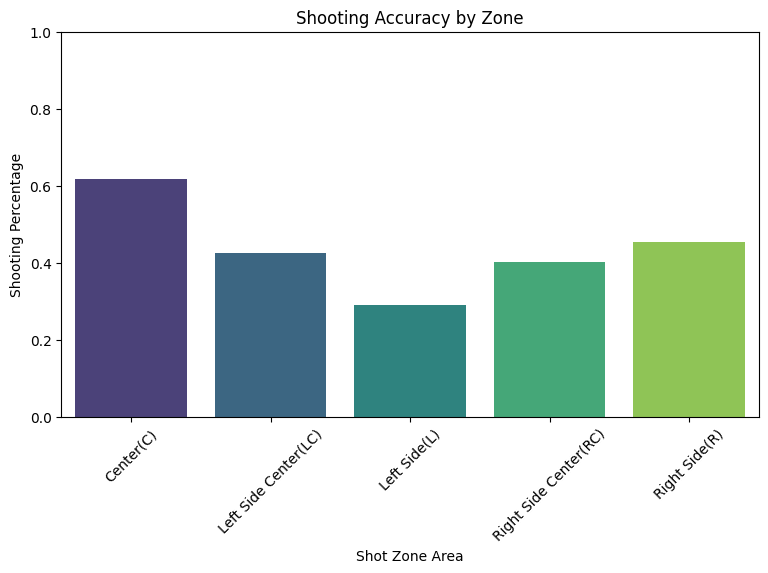

In [88]:
# ====== 2. Clean Outliers ======

# Filter out data where LOC_Y > 470
df_cleaned = df[df["LOC_Y"] <= 470]

# ====== 3. Calculate Shooting Accuracy in Different Zones ======
shot_zone_stats = df_cleaned.groupby("SHOT_ZONE_AREA")["SHOT_MADE_FLAG"].mean().reset_index()

# ====== 4. Plot a Bar Chart ======
plt.figure(figsize=(9, 5))
sns.barplot(data=shot_zone_stats, x="SHOT_ZONE_AREA", y="SHOT_MADE_FLAG", hue="SHOT_ZONE_AREA", palette="viridis", legend=False)
plt.title("Shooting Accuracy by Zone")
plt.xlabel("Shot Zone Area")
plt.ylabel("Shooting Percentage")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

## Exploratory Data Analysis (EDA) with visualizations

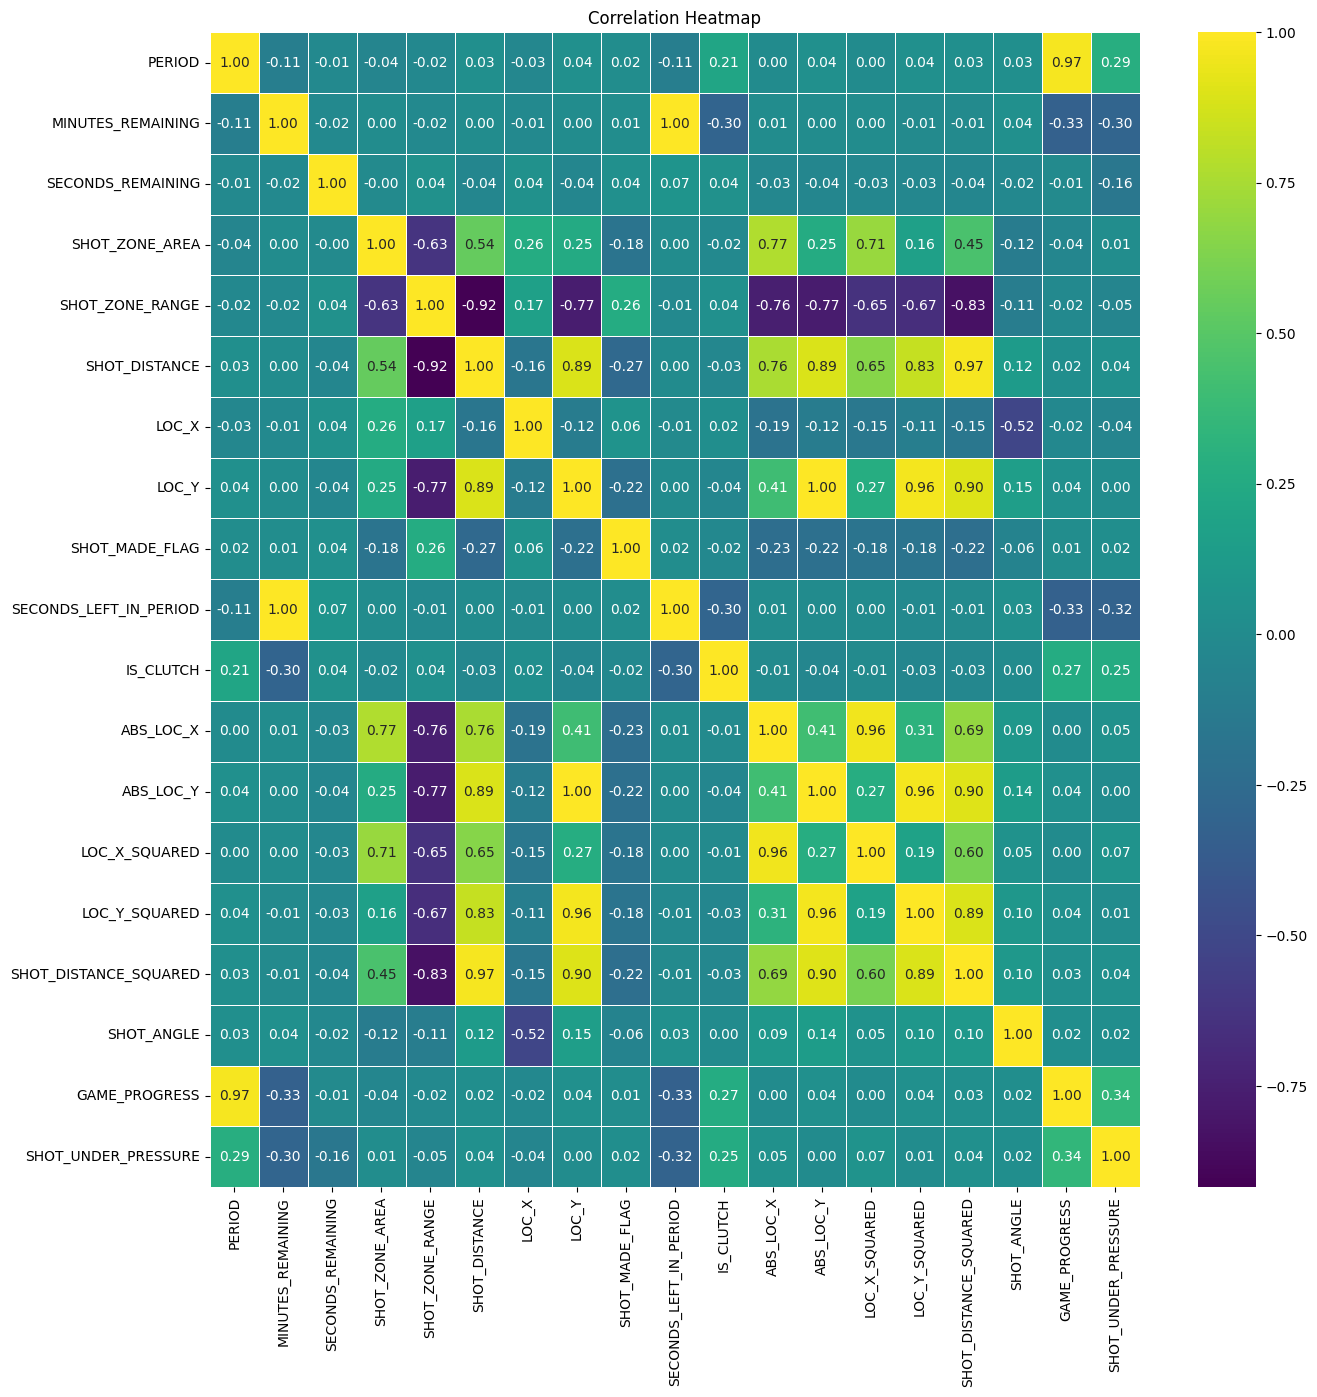

SHOT_MADE_FLAG            1.000000
SHOT_DISTANCE             0.267843
SHOT_ZONE_RANGE           0.260389
ABS_LOC_X                 0.232451
SHOT_DISTANCE_SQUARED     0.224906
ABS_LOC_Y                 0.215549
LOC_Y                     0.215292
LOC_X_SQUARED             0.181004
SHOT_ZONE_AREA            0.179680
LOC_Y_SQUARED             0.177407
LOC_X                     0.064169
SHOT_ANGLE                0.057125
SECONDS_REMAINING         0.039897
IS_CLUTCH                 0.022831
SHOT_UNDER_PRESSURE       0.018896
PERIOD                    0.017571
SECONDS_LEFT_IN_PERIOD    0.016432
GAME_PROGRESS             0.013758
MINUTES_REMAINING         0.012893
Name: SHOT_MADE_FLAG, dtype: float64

The variable with the highest correlation is: SHOT_DISTANCE


In [89]:
#Calculate the correlation between variables and the target value.

columns_to_drop = ["GRID_TYPE", "GAME_ID", "GAME_EVENT_ID", "PLAYER_ID", "PLAYER_NAME", 
                       "TEAM_ID", "TEAM_NAME", "GAME_DATE", "HTM", "VTM", "SHOT_ATTEMPTED_FLAG"]


# time left of this period
df["SECONDS_LEFT_IN_PERIOD"] = df["MINUTES_REMAINING"] * 60 + df["SECONDS_REMAINING"]
df["IS_CLUTCH"] = ((df["PERIOD"] >= 4) & (df["SECONDS_LEFT_IN_PERIOD"] <= 60)).astype(int)

# SHOT_DISTANCE_SQUARED
df["ABS_LOC_X"] = df["LOC_X"].abs()
df["ABS_LOC_Y"] = df["LOC_Y"].abs()
df["LOC_X_SQUARED"] = df["LOC_X"] ** 2
df["LOC_Y_SQUARED"] = df["LOC_Y"] ** 2
df["SHOT_DISTANCE_SQUARED"] = df["SHOT_DISTANCE"] ** 2

df["SHOT_ANGLE"] = np.degrees(np.arctan2(df["LOC_Y"], df["LOC_X"]))

df["GAME_PROGRESS"] = ((df["PERIOD"] - 1) * 12 + (12 - df["MINUTES_REMAINING"])) / 48
df["SHOT_UNDER_PRESSURE"] = ((df["PERIOD"] >= 4) & (df["MINUTES_REMAINING"] <= 3) & (df["SECONDS_REMAINING"] <= 30)).astype(int)

categorical_features = ["SHOT_ZONE_AREA", "SHOT_ZONE_RANGE"]
for col in categorical_features:
    df[col] = df[col].astype("category").cat.codes

df_cleaned = df.drop(columns=columns_to_drop, errors="ignore")

correlation_matrix = df_cleaned.corr(numeric_only=True)
shot_correlation = correlation_matrix["SHOT_MADE_FLAG"].abs().sort_values(ascending=False)
max_correlation_var = shot_correlation.index[1]

plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

display(shot_correlation)

print(f"The variable with the highest correlation is: {max_correlation_var}")

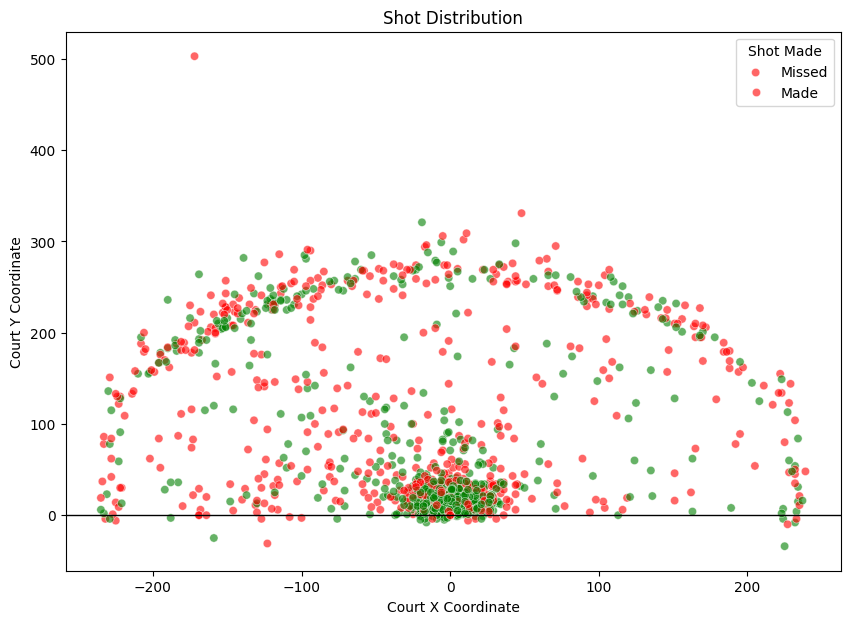

In [90]:
# Convert data types to ensure X and Y coordinates are numeric.
df['LOC_X'] = pd.to_numeric(df['LOC_X'], errors='coerce')
df['LOC_Y'] = pd.to_numeric(df['LOC_Y'], errors='coerce')

# Plot a scatter chart of shot attempts.
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="LOC_X", y="LOC_Y", hue="SHOT_MADE_FLAG", 
                palette={0: "red", 1: "green"}, alpha=0.6)

# Add reference lines to mark the hoop location.
plt.axhline(0, color="black", linewidth=1)  

# Add titles and lables
plt.title("Shot Distribution")
plt.xlabel("Court X Coordinate")
plt.ylabel("Court Y Coordinate")
plt.legend(title="Shot Made", labels=["Missed", "Made"])

plt.show()

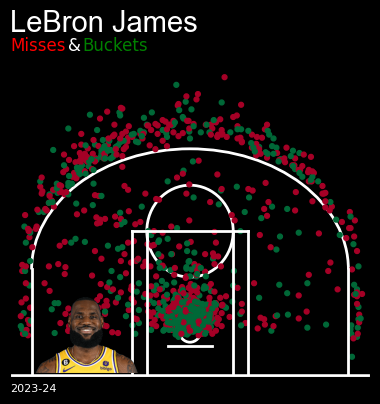

In [91]:
# We need to improve this scatter plot to better reflect the real court.
# In the ShotCharts class, we implement the real court and display made and missed shots on it.

chart1 = ShotCharts.makes_misses_chart(shot_data, name, seasons)
plt.show()

xmin: -250, xmax: 250, ymin: -47.5, ymax: 422.5
xmin: -250, xmax: 250, ymin: -47.5, ymax: 422.5


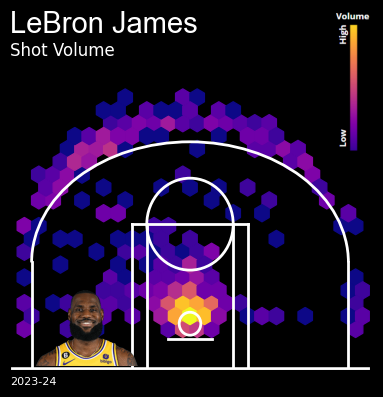

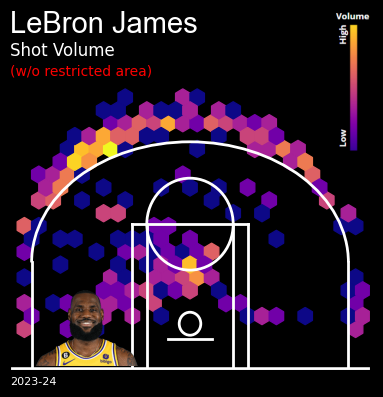

In [92]:
# Volume Chart 
# Purpose: To visualize the distribution of a player’s shot attempts, highlighting the areas where they take the most shots.

# RA=True: Includes all shot data (default).
# RA=False: Excludes the restricted area, emphasizing mid-range and three-point shots.

# Darker areas represent zones where the player takes more shots.
# Lighter areas indicate fewer shot attempts or rarely attempted shots.

chart2 = ShotCharts.volume_chart(shot_data, name, seasons)
chart3 = ShotCharts.volume_chart(shot_data, name, seasons, RA=False)
plt.show()

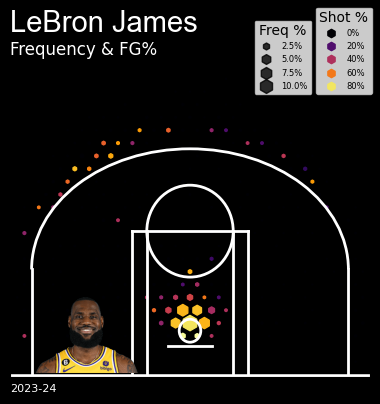

In [93]:
# Frequency Chart

# Evaluate a player’s scoring efficiency in different areas by combining shot frequency and accuracy.
# Size (hexagon area) represents shot frequency (proportion of attempts from that area).
# Color indicates the shooting accuracy in that area.

chart4 = ShotCharts.frequency_chart(shot_data, name, seasons)
plt.show()